In [ ]:
import pandas as pd
import numpy as np
from itertools import groupby
import plot_likert
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import chisquare

from IPython.display import display, HTML

# Load the CSV file into a DataFrame
df = pd.read_csv('responses.csv')

# Display the DataFrame
for column in df.columns.tolist():
  print(column)

Survey 
Participant
User Story
Domain
Machine Learning Keyword
Comprehensibility
Actionability
Realism
Different format [Yes/No]
Alternative


General Distributions


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare

# Assuming you have a DataFrame 'df' with columns 'Comprehensibility', 'Actionability', 'Realism', and 'Category'

# Calculate statistics for each column
comprehensibility_stats = df['Comprehensibility'].describe()
actionability_stats = df['Actionability'].describe()
realism_stats = df['Realism'].describe()

# Create a new DataFrame to store the statistics
statistics_df = pd.DataFrame({
    'Comprehensibility': comprehensibility_stats,
    'Actionability': actionability_stats,
    'Realism': realism_stats
})

# Calculate quartiles separately since they are not part of the 'describe()' function
comprehensibility_quartiles = np.percentile(df['Comprehensibility'], [25, 50, 75])
actionability_quartiles = np.percentile(df['Actionability'], [25, 50, 75])
realism_quartiles = np.percentile(df['Realism'], [25, 50, 75])

# Add quartiles to the statistics DataFrame
statistics_df.loc['25%'] = [comprehensibility_quartiles[0], actionability_quartiles[0], realism_quartiles[0]]
statistics_df.loc['50%'] = [comprehensibility_quartiles[1], actionability_quartiles[1], realism_quartiles[1]]
statistics_df.loc['75%'] = [comprehensibility_quartiles[2], actionability_quartiles[2], realism_quartiles[2]]

# Rename index to appropriate labels
statistics_df.rename(index={'mean': 'Mean', 'std': 'Standard Deviation'}, inplace=True)

display(statistics_df.round(3).transpose())


,count,Mean,Standard Deviation,min,25%,50%,75%,max
Comprehensibility,750.0,4.043,0.936,1.0,4.0,4.0,5.0,5.0
Actionability,750.0,3.815,0.965,1.0,3.0,4.0,5.0,5.0
Realism,750.0,3.732,1.111,1.0,3.0,4.0,5.0,5.0


,Comprehensibility,Actionability,Realism
Not at all,11,11,30
Slightly,45,64,82
Moderately,112,173,164
Very,315,307,257
Extremely,267,195,217


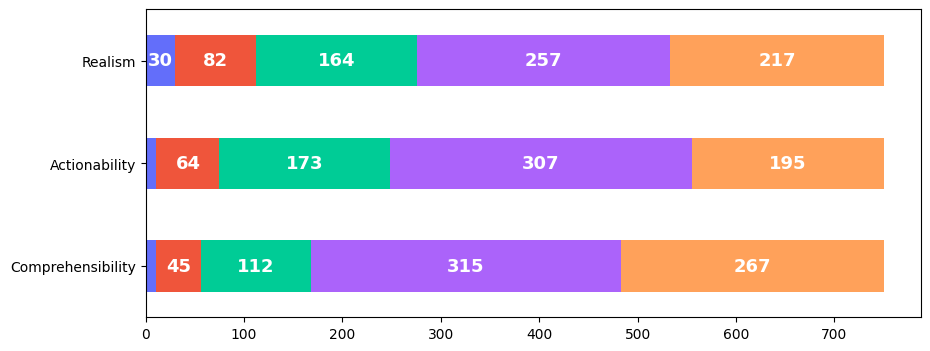

In [ ]:
index = ["Not at all", "Slightly", "Moderately", "Very", "Extremely"]

# Statistical notion diagram
graph_Comprehensibility = df['Comprehensibility'].replace({1: "Not at all", 2: "Slightly", 3: "Moderately", 4: "Very", 5: "Extremely"})
graph_Actionability = df['Actionability'].replace({1: "Not at all", 2: "Slightly", 3: "Moderately", 4: "Very", 5: "Extremely"})
graph_Realism = df['Realism'].replace({1: "Not at all", 2: "Slightly", 3: "Moderately", 4: "Very", 5: "Extremely"})
graph_df = pd.concat([graph_Comprehensibility.value_counts().fillna(0), graph_Actionability.value_counts().fillna(0), graph_Realism.value_counts().fillna(0)], axis = 1).fillna(0).reindex(index)

display(graph_df)

ax = graph_df.transpose().plot.barh(stacked=True, color= px.colors.qualitative.Plotly[0:6], figsize=(10,4),legend=False)

# Add values inside the bars with padding
for container in ax.containers:
    for bar in container:
        width = bar.get_width()
        label_position = bar.get_x() + width / 2
        label_value = int(bar.get_width())
        if (bar.get_width() / 2) > 10: ax.text(label_position, bar.get_y() + bar.get_height() / 2, label_value,
                ha='center', va='center', color='white', fontsize=13, fontweight='bold')



Mean Values for each User Story

In [ ]:
import pandas as pd

# Assuming 'df' is the DataFrame containing the columns 'User Story', 'Comprehensibility', 'Actionability', and 'Realism'

# Group the data by 'User Story' and calculate the mean for each group
mean_values = df.groupby('User Story').mean()

# Count the number of rows (entries) in each group
row_counts = df['User Story'].value_counts().rename('Number of Evaluations')

# Combine mean values and row counts into a single DataFrame
summary_table = pd.concat([mean_values, row_counts], axis=1)

display(summary_table)


<ipython-input-35-c92826247079>:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mean_values = df.groupby('User Story').mean()


,Comprehensibility,Actionability,Realism,Number of Evaluations
"A nephrologist needs to review multiple patient cases to identify potential patterns in kidney disease. They use an automatic summarization tool to generate summaries of each case, allowing them to quickly identify common symptoms and risk factors without having to read each case in full.",2.5,3.0,2.0,2
"A network administrator wants to develop a bidirectional recurrent neural network that can predict network traffic patterns based on past data, network topology, and external factors.",4.5,4.0,2.5,2
A pharmaceutical company is using kohonen neural networks to analyze large data sets related to drug development and identify potential new compounds.,4.5,4.0,3.5,2
"As a bioinformatics researcher, I want to use decision boundary algorithms to classify different types of cells based on their gene expression profiles, so that I can better understand the underlying biological mechanisms and identify potential targets for drug development.",3.0,3.0,2.5,2
"As a bioinformatics researcher, I want to use random forest algorithms to analyze large sets of genomic data and identify patterns of gene expression, so that I can better understand the underlying biological mechanisms that control cell function.",4.0,4.5,4.5,2
...,...,...,...,...
"As an urban planner, I want to use multi-task learning to predict both urban growth and crime rate based on demographic and socio-economic data, land use, and historical data, so that I can make more informed decisions about land use and urban development while ensuring public safety.",4.5,5.0,4.5,2
"As an urban planner, I want to use multifactor dimensionality reduction to identify the combination of demographic, socio-economic, and land use factors that contribute to urban growth and development, so that I can make more informed decisions about land use and urban planning.",5.0,5.0,5.0,2
"As an urban planner, I want to use multinomial logistic regression to predict the impact of urban development projects on the environment and society to enhance urban sustainability planning.",4.5,4.0,4.0,2
"As an urban planner, I want to use preference learning to identify which urban design elements (e.g., green space, public art) are most preferred by residents in a specific neighborhood.",4.0,4.5,4.5,2


In [ ]:
# Calculate statistics for each column
comprehensibility_stats = mean_values['Comprehensibility'].describe()
actionability_stats = mean_values['Actionability'].describe()
realism_stats = mean_values['Realism'].describe()

# Create a new DataFrame to store the statistics
statistics_df = pd.DataFrame({
    'Comprehensibility': comprehensibility_stats,
    'Actionability': actionability_stats,
    'Realism': realism_stats
})

# Calculate quartiles separately since they are not part of the 'describe()' function
comprehensibility_quartiles = np.percentile(df['Comprehensibility'], [25, 50, 75])
actionability_quartiles = np.percentile(df['Actionability'], [25, 50, 75])
realism_quartiles = np.percentile(df['Realism'], [25, 50, 75])

# Add quartiles to the statistics DataFrame
statistics_df.loc['25%'] = [comprehensibility_quartiles[0], actionability_quartiles[0], realism_quartiles[0]]
statistics_df.loc['50%'] = [comprehensibility_quartiles[1], actionability_quartiles[1], realism_quartiles[1]]
statistics_df.loc['75%'] = [comprehensibility_quartiles[2], actionability_quartiles[2], realism_quartiles[2]]

# Rename index to appropriate labels
statistics_df.rename(index={'mean': 'Mean', 'std': 'Standard Deviation'}, inplace=True)

display(statistics_df.transpose().round(3))

,count,Mean,Standard Deviation,min,25%,50%,75%,max
Comprehensibility,375.0,4.043,0.638,2.0,4.0,4.0,5.0,5.0
Actionability,375.0,3.815,0.665,1.5,3.0,4.0,5.0,5.0
Realism,375.0,3.732,0.782,1.5,3.0,4.0,5.0,5.0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


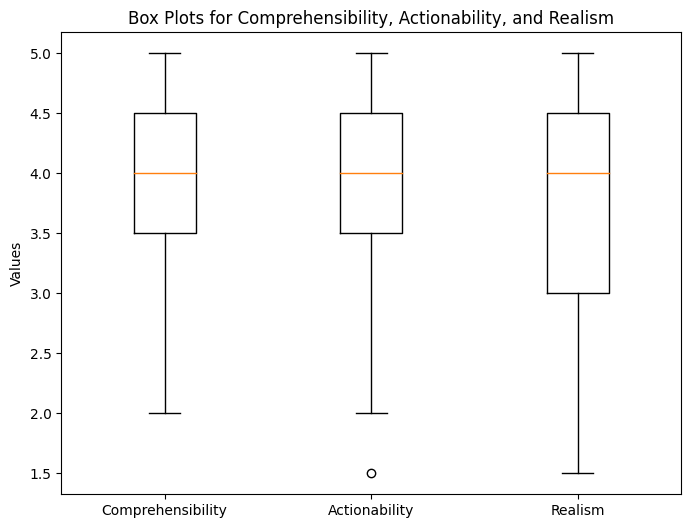

In [ ]:
# Box plots for each indicator
plt.figure(figsize=(8, 6))
plt.boxplot([mean_values['Comprehensibility'][1:],
             mean_values['Actionability'][1:],
             mean_values['Realism'][1:]],
            labels=['Comprehensibility', 'Actionability', 'Realism'])
plt.title('Box Plots for Comprehensibility, Actionability, and Realism')
plt.ylabel('Values')
plt.show()

#Dividing by domain

In [ ]:
import pandas as pd

# Assuming 'df' is the DataFrame containing the columns described in the question

# Create a pivot table for each indicator value and application domain
comprehensibility_pivot = df.pivot_table(index='Comprehensibility', columns='Domain', values='Participant', aggfunc='count')
actionability_pivot = df.pivot_table(index='Actionability', columns='Domain', values='Participant', aggfunc='count')
realism_pivot = df.pivot_table(index='Realism', columns='Domain', values='Participant', aggfunc='count')

# Fill NA values with 0
comprehensibility_pivot.fillna(0, inplace=True)
actionability_pivot.fillna(0, inplace=True)
realism_pivot.fillna(0, inplace=True)

# Concatenate all pivot tables into a single table and transpose it
all_pivot_tables = pd.concat([comprehensibility_pivot, actionability_pivot, realism_pivot], keys=['Comprehensibility', 'Actionability', 'Realism'], axis=0).transpose()

# Add a final column for the total number of responses for the 'Realism' indicator
all_pivot_tables['# of opinion'] =  realism_pivot.sum(axis=0)

# Print the aggregated table
print("Aggregated Pivot Table:")
display(all_pivot_tables.round(0))


Aggregated Pivot Table:


Comprehensibility                       Actionability  \
Comprehensibility                   1    2    3     4     5             1   
Domain                                                                      
Biology                           0.0  1.0  3.0   5.0   3.0           0.0   
Cardiology                        0.0  1.0  0.0  13.0   6.0           0.0   
Computer Networks                 0.0  3.0  2.0   9.0   8.0           0.0   
Computer Vision                   0.0  1.0  2.0  12.0  13.0           0.0   
Demography                        1.0  3.0  7.0  16.0  11.0           1.0   
Dermatology                       0.0  3.0  6.0  11.0   6.0           1.0   
Economics                         0.0  0.0  5.0   9.0   8.0           0.0   
Education                         0.0  0.0  5.0   6.0   7.0           0.0   
Endocrinology                     0.0  6.0  3.0  10.0  11.0           0.0   
Finance & Marketing               0.0  0.0  1.0   3.0   2.0           0.0   
Health                            0.0  1.0  4.0  12.0  11.0           0.0   
Information Systems               1.0  3.0  3.0   8.0  13.0           1.0   
Law                               0.0  1.0  4.0  13.0  10.0           0.0   
Library                           1.0  0.0  2.0   7.0   2.0           0.0   
Linguistics                       0.0  2.0  1.0  10.0   9.0           0.0   
Literature                        2.0  3.0  3.0  15.0   5.0           1.0   
Medicine                          0.0  0.0  4.0   4.0  10.0           0.0   
Movies                            0.0  0.0  6.0  10.0  12.0           1.0   
Music                             0.0  0.0  4.0   8.0  12.0           0.0   
Nephrology                        2.0  1.0  4.0  14.0   7.0           1.0   
News                              0.0  2.0  1.0   5.0   6.0           0.0   
Pediatrics                        2.0  1.0  4.0   9.0   6.0           1.0   
Pharmacology                      0.0  0.0  2.0   7.0   9.0           0.0   
Plant Science                     0.0  0.0  4.0   9.0   9.0           0.0   
Political Science                 0.0  1.0  3.0  10.0   4.0           0.0   
Psychology                        0.0  0.0  6.0   5.0   3.0           0.0   
Radiology                         1.0  0.0  2.0   1.0   6.0           1.0   
Social Media                      0.0  1.0  4.0   8.0   9.0           0.0   
Social Networks                   1.0  3.0  3.0  11.0   6.0           1.0   
Social Work                       0.0  2.0  2.0  10.0   4.0           1.0   
Sociology                         0.0  2.0  1.0  13.0   8.0           0.0   
Sport                             0.0  2.0  5.0  13.0  12.0           1.0   
Transportation                    0.0  0.0  4.0   8.0  12.0           0.0   
Urban Studies                     0.0  2.0  2.0  11.0   7.0           0.0   

                                           Realism                         \
Comprehensibility      2     3     4     5       1    2     3     4     5   
Domain                                                                      
Biology              1.0   3.0   6.0   2.0     0.0  1.0   6.0   1.0   4.0   
Cardiology           1.0   5.0   8.0   6.0     0.0  2.0   3.0  10.0   5.0   
Computer Networks    1.0   5.0   9.0   7.0     1.0  3.0   5.0   8.0   5.0   
Computer Vision      2.0   5.0  13.0   8.0     0.0  1.0   3.0  17.0   7.0   
Demography           3.0  11.0  13.0  10.0     2.0  3.0   8.0  11.0  14.0   
Dermatology          3.0   8.0  10.0   4.0     1.0  3.0   8.0   9.0   5.0   
Economics            3.0   3.0   8.0   8.0     1.0  1.0   5.0   7.0   8.0   
Education            1.0   1.0  11.0   5.0     0.0  2.0   6.0   6.0   4.0   
Endocrinology        2.0  12.0  10.0   6.0     1.0  6.0   3.0  10.0  10.0   
Finance & Marketing  0.0   2.0   2.0   2.0     0.0  0.0   0.0   2.0   4.0   
Health               3.0   5.0  14.0   6.0     0.0  3.0   7.0  10.0   8.0   
Information Systems  3.0   4.0   8.0  12.0     1.0  4.0   6.0   7.0  10.0   
Law            

In [ ]:
import pandas as pd

# Calculate the number of unique values in the 'Domain' column
num_unique_domains = df['Domain'].nunique()

# Print the number of unique values
print("Number of Application Domain:", num_unique_domains)

# Group by 'Domain' and calculate statistics for each indicator
grouped_stats = df.groupby('Domain').agg({
    'Comprehensibility': ['mean', 'median', 'std', ('Opinions count', 'count'), 'min', 'max'],
    'Actionability': ['mean', 'median', 'std', 'min', 'max'],
    'Realism': ['mean', 'median', 'std', 'min', 'max']
})

# Flatten the multi-level columns to make it easier to work with
grouped_stats.columns = [' '.join(col).strip() for col in grouped_stats.columns.values]

# Rename each count column as "Opinions count"
grouped_stats.rename(columns={
    'Comprehensibility Opinions count': '# of response'
}, inplace=True)

# Print the tables for each indicator
print("Comprehensibility Stats:")
display(grouped_stats[['# of response', 'Comprehensibility mean', 'Comprehensibility median', 'Comprehensibility std',
                     'Comprehensibility min', 'Comprehensibility max']])

print("\nActionability Stats:")
display(grouped_stats[['# of response', 'Actionability mean', 'Actionability median', 'Actionability std',
                     'Actionability min', 'Actionability max']])

print("\nRealism Stats:")
display(grouped_stats[['# of response', 'Realism mean', 'Realism median', 'Realism std',
                      'Realism min', 'Realism max']])


Number of Application Domain: 34
Comprehensibility Stats:


,# of response,Comprehensibility mean,Comprehensibility median,Comprehensibility std,Comprehensibility min,Comprehensibility max
Domain,,,,,,
Biology,12,3.833333,4.0,0.937437,2,5
Cardiology,20,4.200000,4.0,0.695852,2,5
Computer Networks,22,4.000000,4.0,1.023533,2,5
Computer Vision,28,4.321429,4.0,0.772374,2,5
Demography,38,3.868421,4.0,1.017975,1,5
Dermatology,26,3.769231,4.0,0.951113,2,5
Economics,22,4.136364,4.0,0.774317,3,5
Education,18,4.111111,4.0,0.832352,3,5
Endocrinology,30,3.866667,4.0,1.136642,2,5



Actionability Stats:


,# of response,Actionability mean,Actionability median,Actionability std,Actionability min,Actionability max
Domain,,,,,,
Biology,12,3.750000,4.0,0.866025,2,5
Cardiology,20,3.950000,4.0,0.887041,2,5
Computer Networks,22,4.000000,4.0,0.872872,2,5
Computer Vision,28,3.964286,4.0,0.881167,2,5
Demography,38,3.736842,4.0,1.031509,1,5
Dermatology,26,3.500000,4.0,1.029563,1,5
Economics,22,3.954545,4.0,1.045502,2,5
Education,18,4.111111,4.0,0.758395,2,5
Endocrinology,30,3.666667,4.0,0.884087,2,5



Realism Stats:


,# of response,Realism mean,Realism median,Realism std,Realism min,Realism max
Domain,,,,,,
Biology,12,3.666667,3.0,1.073087,2,5
Cardiology,20,3.900000,4.0,0.911910,2,5
Computer Networks,22,3.590909,4.0,1.140555,1,5
Computer Vision,28,4.071429,4.0,0.716399,2,5
Demography,38,3.842105,4.0,1.174649,1,5
Dermatology,26,3.538462,4.0,1.066987,1,5
Economics,22,3.909091,4.0,1.108800,1,5
Education,18,3.666667,4.0,0.970143,2,5
Endocrinology,30,3.733333,4.0,1.229896,1,5


Open Ended Opinions

In [1]:
import pandas as pd


# Assuming 'df' is the original DataFrame containing the columns described

# Create the subdf with the specified columns
subdf = df[['Participant', 'User Story', 'Alternative']].dropna(subset=['Alternative'])

print(subdf)
# Save 'subdf' as a CSV file
subdf.to_csv('subdf.csv', index=False)

print("CSV file 'open-ended-opinions.csv' has been created.")


NameError: ignored